Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline

Load the Dataset

In [ ]:
df = pd.read_csv('retail_sales.csv')

Data cleaning

In [ ]:
df.head()

,Date,Category,Sales,Quantity,Profit,Region
0,1/1/2023,Electronics,1149.014246,11.0,383.664245,North
1,1/1/2023,Clothing,958.520710,7.0,224.054049,East
2,1/1/2023,Home Goods,1473.763845,2.0,466.593090,South
3,1/1/2023,Sports,1230.230419,6.0,123.310460,West
4,1/1/2023,NaN?,828.585950,12.0,88.591355,East


In [ ]:
df.sample(5)

,Date,Category,Sales,Quantity,Profit,Region
668,5/14/2023,Sports,1471.844392,19.0,304.459393,South
565,4/24/2023,Electronics,1319.758300,15.0,213.093959,North
788,6/7/2023,Sports,961.735264,15.0,253.274646,North
1594,11/15/2023,Books,1111.063567,1.0,269.125016,South
972,7/14/2023,Home Goods,876.583051,8.0,145.435680,West


In [ ]:
df.tail()

,Date,Category,Sales,Quantity,Profit,Region
1820,12/31/2023,Electronics,1132.749004,14.0,353.464221,West
1821,12/31/2023,Clothing,679.261971,8.0,183.860200,North
1822,12/31/2023,Home Goods,1193.733728,10.0,359.010938,South
1823,12/31/2023,Sports,1076.118706,17.0,259.570916,North
1824,12/31/2023,Books,703.973443,14.0,134.106006,East


In [ ]:
df.shape

(1825, 6)

In [ ]:
df.size

10950

In [ ]:
df.columns

Index(['Date', 'Category', 'Sales', 'Quantity', 'Profit', 'Region'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      1825 non-null   object 
 1   Category  1821 non-null   object 
 2   Sales     1823 non-null   float64
 3   Quantity  1820 non-null   float64
 4   Profit    1825 non-null   float64
 5   Region    1820 non-null   object 
dtypes: float64(3), object(3)
memory usage: 85.7+ KB


In [ ]:
df.describe()

,Sales,Quantity,Profit
count,1823.000000,1820.000000,1825.000000
mean,980.482677,10.053846,248.696130
std,336.756618,5.515370,118.159627
min,0.000000,0.000000,0.000000
25%,784.071354,5.000000,156.916498
50%,997.725134,10.000000,229.344557
75%,1208.512721,15.000000,324.867847
max,1888.932537,19.000000,703.228418




Data Cleaning
Check Missing Values

In [ ]:
df.isnull().sum()

,0
Date,0
Category,4
Sales,2
Quantity,5
Profit,0
Region,5


In [ ]:
df['Category'] = df['Category'].fillna(df['Category'].mode()[0])

In [ ]:
df['Sales'] = df['Sales'].fillna(df['Sales'].mode()[0])

In [ ]:
df['Quantity']= df['Quantity'].fillna(df['Quantity'].mode()[0])

In [ ]:
df['Region']= df['Region'].fillna(df['Region'].mode()[0])

In [ ]:
df.isnull().sum()

,0
Date,0
Category,0
Sales,0
Quantity,0
Profit,0
Region,0


Check Duplicate Records

In [ ]:
df.duplicated().sum()

np.int64(0)

Filtering Data

In [ ]:
df[df['Sales'] > 500]

,Date,Category,Sales,Quantity,Profit,Region
0,1/1/2023,Electronics,1149.014246,11.0,383.664245,North
1,1/1/2023,Clothing,958.520710,7.0,224.054049,East
2,1/1/2023,Home Goods,1473.763845,2.0,466.593090,South
3,1/1/2023,Sports,1230.230419,6.0,123.310460,West
4,1/1/2023,NaN?,828.585950,12.0,88.591355,East
...,...,...,...,...,...,...
1820,12/31/2023,Electronics,1132.749004,14.0,353.464221,West
1821,12/31/2023,Clothing,679.261971,8.0,183.860200,North
1822,12/31/2023,Home Goods,1193.733728,10.0,359.010938,South
1823,12/31/2023,Sports,1076.118706,17.0,259.570916,North


In [ ]:
df[df['Category'] == 'Electronics']

,Date,Category,Sales,Quantity,Profit,Region
0,1/1/2023,Electronics,1149.014246,11.0,383.664245,North
5,1/2/2023,Electronics,722.775149,10.0,82.396149,West
20,1/5/2023,Electronics,856.000000,5.0,273.041863,West
25,1/6/2023,Electronics,916.000000,4.0,340.909220,East
30,1/7/2023,Electronics,1411.558640,7.0,525.168321,North
...,...,...,...,...,...,...
1800,12/27/2023,Electronics,680.960990,7.0,113.403054,North
1805,12/28/2023,Electronics,1213.609516,2.0,203.521557,East
1810,12/29/2023,Electronics,782.926023,2.0,220.857117,South
1815,12/30/2023,Electronics,1250.682408,1.0,128.255822,South


In [ ]:
df[df['Region'] == 'South']

,Date,Category,Sales,Quantity,Profit,Region
2,1/1/2023,Home Goods,1473.763845,2.0,466.593090,South
10,1/3/2023,Clothing,1246.763474,2.0,283.696992,South
13,1/3/2023,Sports,0.000000,15.0,371.526571,South
23,1/5/2023,Sports,1235.262456,15.0,281.963856,South
27,1/6/2023,Home Goods,1686.167795,19.0,250.170622,South
...,...,...,...,...,...,...
1810,12/29/2023,Electronics,782.926023,2.0,220.857117,South
1813,12/29/2023,Sports,371.968313,1.0,93.302684,South
1815,12/30/2023,Electronics,1250.682408,1.0,128.255822,South
1819,12/30/2023,Books,856.742773,7.0,87.181646,South


In [ ]:
df[df['Category'] == 'Sports']

,Date,Category,Sales,Quantity,Profit,Region
3,1/1/2023,Sports,1230.230419,6.0,123.310460,West
8,1/2/2023,Sports,819.923845,2.0,250.298077,East
13,1/3/2023,Sports,0.000000,15.0,371.526571,South
23,1/5/2023,Sports,1235.262456,15.0,281.963856,South
28,1/6/2023,Sports,559.909634,6.0,132.676395,West
...,...,...,...,...,...,...
1803,12/27/2023,Sports,1284.552563,5.0,148.622548,West
1808,12/28/2023,Sports,1310.164316,2.0,222.441216,East
1813,12/29/2023,Sports,371.968313,1.0,93.302684,South
1818,12/30/2023,Sports,1147.267364,13.0,340.509420,East


Sorting Data

In [ ]:
df.sort_values(by='Profit')

,Date,Category,Sales,Quantity,Profit,Region
465,4/4/2023,Electronics,0.000000,12.0,0.000000,West
312,3/4/2023,Home Goods,0.000000,19.0,0.000000,West
1141,8/17/2023,Clothing,43.656557,8.0,8.140877,South
1666,11/30/2023,Clothing,70.098843,1.0,9.795696,South
56,1/12/2023,Clothing,136.162932,9.0,20.802643,West
...,...,...,...,...,...,...
750,5/31/2023,Electronics,1637.930677,11.0,636.877412,West
1489,10/25/2023,Books,1655.733944,7.0,645.714161,North
576,4/26/2023,Clothing,1763.100369,8.0,649.168113,West
1734,12/13/2023,Books,1643.510926,15.0,652.843041,West


In [ ]:
df.sort_values(by='Profit', ascending=False)

,Date,Category,Sales,Quantity,Profit,Region
290,2/28/2023,Electronics,1779.311393,12.0,703.228418,South
1734,12/13/2023,Books,1643.510926,15.0,652.843041,West
576,4/26/2023,Clothing,1763.100369,8.0,649.168113,West
1489,10/25/2023,Books,1655.733944,7.0,645.714161,North
750,5/31/2023,Electronics,1637.930677,11.0,636.877412,West
...,...,...,...,...,...,...
56,1/12/2023,Clothing,136.162932,9.0,20.802643,West
1666,11/30/2023,Clothing,70.098843,1.0,9.795696,South
1141,8/17/2023,Clothing,43.656557,8.0,8.140877,South
465,4/4/2023,Electronics,0.000000,12.0,0.000000,West


In [ ]:
df.sort_values(by='Sales', ascending=False)

,Date,Category,Sales,Quantity,Profit,Region
1538,11/4/2023,Sports,1888.932537,7.0,624.033248,East
64,1/13/2023,Books,1835.181414,17.0,207.524391,West
1145,8/18/2023,Electronics,1829.793884,2.0,516.259116,West
1190,8/27/2023,Electronics,1790.061382,5.0,184.641417,South
290,2/28/2023,Electronics,1779.311393,12.0,703.228418,South
...,...,...,...,...,...,...
281,2/26/2023,Clothing,0.000000,10.0,286.286667,South
286,2/27/2023,Clothing,0.000000,2.0,139.842676,South
283,2/26/2023,Sports,0.000000,11.0,232.319471,East
59,1/12/2023,Books,0.000000,1.0,362.747466,East


Sales Statistics

In [ ]:
df['Sales'].var()

114333.6244474672

In [ ]:
df['Sales'].std()

338.1325545514173

In [ ]:
df['Sales'].median()

996.596443067416

In [ ]:
df['Sales'].min()

0.0

In [ ]:
df['Sales'].max()

1888.9325368920124

In [ ]:
df['Sales'].mean()

np.float64(979.4081755840951)

In [ ]:
df['Sales'].sum()

np.float64(1787419.9204409737)

Profit Statistics

In [ ]:
df['Profit'].min()

0.0

In [ ]:
df['Profit'].max()

703.2284178

In [ ]:
df['Profit'].median()

229.3445571579279

In [ ]:
df['Profit'].mean()

np.float64(248.69612996434336)

In [ ]:
df['Profit'].sum()

np.float64(453870.43718492665)

Region-wise Analysis

In [ ]:
region_sales = df.groupby('Region')[['Sales','Profit']].sum()

region_sales

,Sales,Profit
Region,,
East,393441.614509,98973.620400
Nan,1716.710787,545.617726
North,448295.032930,112126.470662
South,473452.192387,119706.953146
West,470514.369828,122517.775250


In [ ]:
df.groupby('Region')['Sales'].mean()

,Sales
Region,
East,988.546770
Nan,1716.710787
North,974.554419
South,968.204892
West,986.403291


Category-wise Analysis

In [ ]:
category_sales = df.groupby('Category')[['Sales','Profit']].sum()

category_sales

,Sales,Profit
Category,,
Books,370971.872558,92304.452141
Clothing,355420.126737,90889.437106
Electronics,364090.406288,90439.697795
Home Goods,347493.827088,87447.820056
NaN?,828.585950,88.591355
Nan,823.190573,253.433301
Null,1106.847949,381.784578
Sports,346685.063298,92065.220851


In [ ]:
df.groupby('Category')['Profit'].mean()

,Profit
Category,
Books,253.583660
Clothing,246.312838
Electronics,250.525479
Home Goods,240.241264
NaN?,88.591355
Nan,253.433301
Null,381.784578
Sports,252.926431


Sub-Category Analysis

In [ ]:
df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

,Sales
Category,
Books,370971.872558
Electronics,364090.406288
Clothing,355420.126737
Home Goods,347493.827088
Sports,346685.063298
Null,1106.847949
NaN?,828.585950
Nan,823.190573


In [ ]:
df[['Sales','Profit','Quantity']].corr()

,Sales,Profit,Quantity
Sales,1.000000,0.517269,0.054137
Profit,0.517269,1.000000,0.028272
Quantity,0.054137,0.028272,1.000000


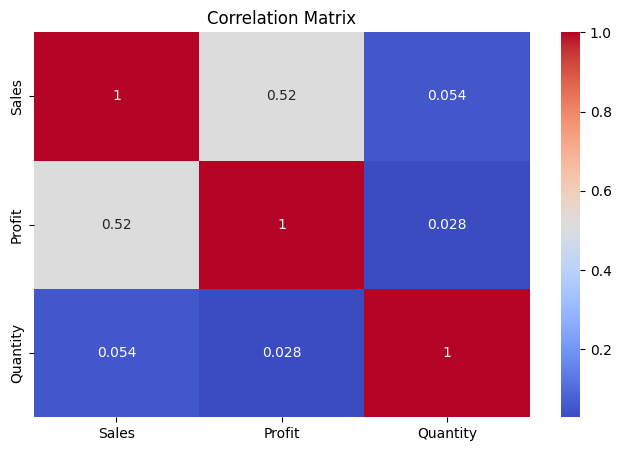

In [ ]:
plt.figure(figsize=(8,5))
sns.heatmap(df[['Sales','Profit','Quantity']].corr(),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Visualization

Bar Chart (Region-wise Sales)


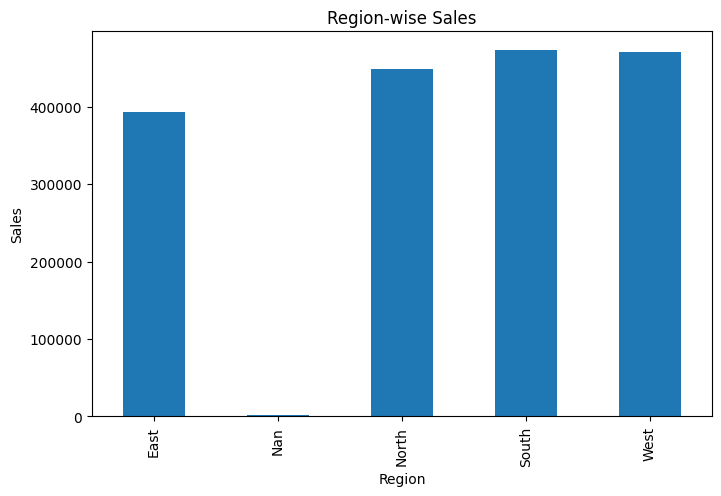

In [ ]:
region_sales['Sales'].plot(kind='bar', figsize=(8,5))
plt.title("Region-wise Sales")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

Line Chart (Monthly Sales)

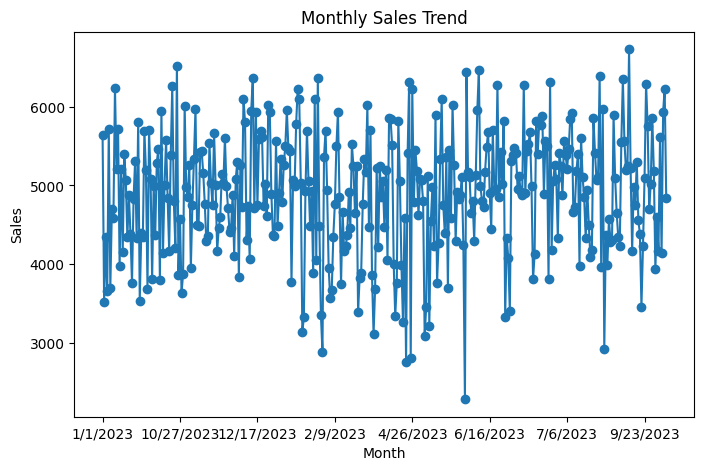

In [ ]:
monthly_sales = df.groupby(df['Date'])['Sales'].sum()

monthly_sales.plot(kind='line', marker='o', figsize=(8,5))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

Histogram (Sales Distribution)

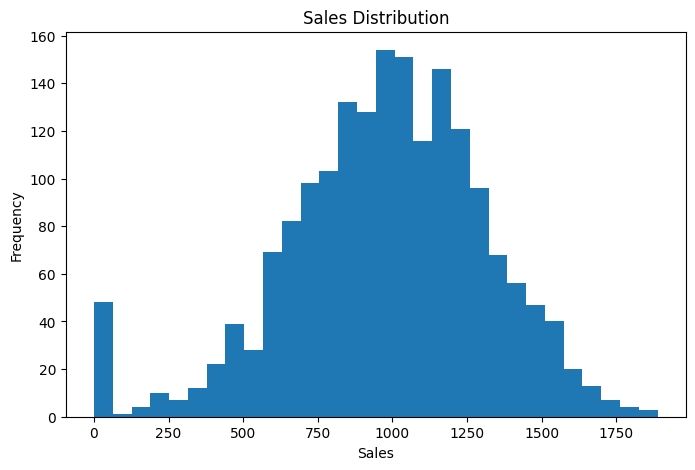

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df['Sales'], bins=30)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

Scatter Plot (Sales vs Profit)

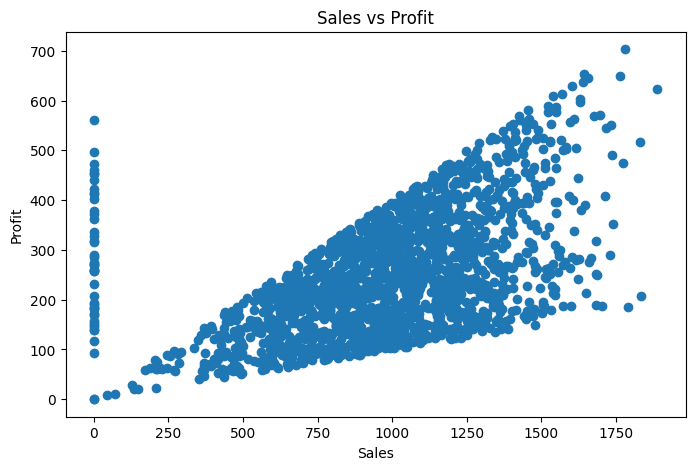

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(df['Sales'], df['Profit'])

plt.title("Sales vs Profit")

plt.xlabel("Sales")

plt.ylabel("Profit")

plt.show()